

# An Introduction to Distributions
### OPIM 5641 - Business Decision Modeling · Module 1.2

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/drdave-teaching/OPIM5641-notebooks/blob/main/2_MonteCarlo/Intro_to_Distributions.ipynb)

*Run me top to bottom - **Runtime → Run all**. Data loads from a stable link, so there's nothing to upload.*


Distributions are how we describe uncertainty when we don't have data. In this notebook we build up the whole Monte Carlo toolkit in one straight line:

1. **Parameters & percentiles** - the knobs on a distribution, and how to describe any list of numbers
2. **The three workhorse continuous distributions** - normal, triangular, uniform (these power almost every simulation in this course)
3. **For loops** - the engine that turns one trial into ten thousand
4. **Your first Monte Carlo simulation** - the retirement nest egg

At the very bottom there's an **appendix** with more distributions you should know - binomial, uniform integers, Poisson - plus the CDF. They're important, genuinely useful tools (counting defects, arrivals, claims); the videos just focus on the three continuous workhorses first.


In [1]:
import numpy as np
import seaborn as sns
from pylab import *

# 🔴 Parameters of a distribution
Vary from distribution to distribution. By turning different knobs, you will create a distribution with a different shape! We will explore this practically in the code below - feel free to check out Wikipedia to see more on the probability distribution (mass) functions!
<!-- 🎙 DAVE TALKING POINTS (invisible when rendered - double-click this cell to read):
- OPEN: "When you have no data, a distribution is how you describe what you DO know."
- Params = knobs on the recipe. A distribution is the recipe; a sample is the list it produces.
- Percentiles = the risk-analysis language for ANY list of numbers.
- THE FIGURE: walk the bands out loud - 68, 95, 99.7. Crisp. No "maybe 67 or 68", no hedging.
- Bottom tick row: "minus-2-sigma and 2.3rd percentile are the SAME statement." That is the bridge.
- CLOSE: "next video we manufacture data with the personality we choose."
-->


# Percentiles
Very useful for describing the shape of the distribution - especially the extremes.

* At the 10th percentile, 10% of the values are at or BELOW this point
* At the 25th percentile, 25% of the values are AT or BELOW this point
* At the 100th percentile, 100% of the values are AT or BELOW this value.

For the **normal** distribution, percentiles and standard deviations line up in a famous pattern - the **empirical rule**: about **68%** of values fall within ±1 standard deviation of the mean, **95%** within ±2, and **99.7%** within ±3. Don't take my word for it - let's draw the picture ourselves:


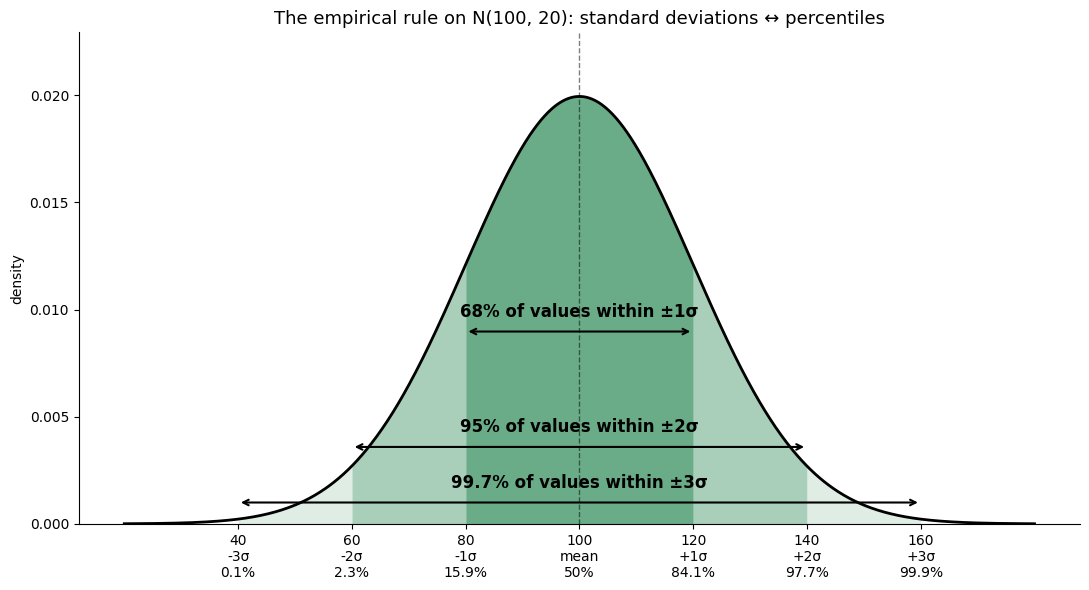

In [2]:
# The empirical rule (68 / 95 / 99.7) - drawn by us, not borrowed from Wikipedia
import numpy as np
import matplotlib.pyplot as plt

mu, sd = 100, 20                       # the same N(100, 20) we sample later in this notebook
x = np.linspace(mu - 4*sd, mu + 4*sd, 1000)
pdf = np.exp(-0.5*((x - mu)/sd)**2) / (sd*np.sqrt(2*np.pi))   # the normal pdf, by hand

fig, ax = plt.subplots(figsize=(11, 6))
ax.plot(x, pdf, color='black', lw=2)

# shade the 3-, 2-, 1-sigma bands (darker = closer to the mean)
for k, alpha in [(3, 0.15), (2, 0.30), (1, 0.50)]:
    band = np.abs(x - mu) <= k*sd
    ax.fill_between(x[band], pdf[band], color='seagreen', alpha=alpha, lw=0)

# label each band with a double-headed arrow
ymax = pdf.max()
for k, frac, y in [(1, '68%', 0.45), (2, '95%', 0.18), (3, '99.7%', 0.05)]:
    ax.annotate('', xy=(mu - k*sd, y*ymax), xytext=(mu + k*sd, y*ymax),
                arrowprops=dict(arrowstyle='<->', color='black', lw=1.5))
    ax.text(mu, (y + 0.035)*ymax, f'{frac} of values within ±{k}σ',
            ha='center', fontsize=12, fontweight='bold')

ax.axvline(mu, color='black', ls='--', lw=1, alpha=0.5)

# x ticks: the value, the sigma count, AND the percentile of that point
ticks = [mu + k*sd for k in range(-3, 4)]
pctls = ['0.1%', '2.3%', '15.9%', '50%', '84.1%', '97.7%', '99.9%']
labels = []
for t, k, pct in zip(ticks, range(-3, 4), pctls):
    mid = 'mean' if k == 0 else f'{k:+d}σ'
    labels.append(f'{t:.0f}\n{mid}\n{pct}')
ax.set_xticks(ticks); ax.set_xticklabels(labels)

ax.set_title('The empirical rule on N(100, 20): standard deviations ↔ percentiles', fontsize=13)
ax.set_ylabel('density'); ax.set_ylim(0, ymax*1.15)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()


Read the bottom row of tick labels: being "2 standard deviations below the mean" and being "at the 2.3rd percentile" are the *same statement*. That's the bridge between the statistics language (σ) and the risk-analysis language (percentiles).

**On your own:** change `mu` and `sd` at the top of the cell and re-run - the bands stretch and slide, but the 68 / 95 / 99.7 pattern never changes. That's what makes it a *rule*.


# 🔴 Sampling from Continuous Distributions
<!-- 🎙 DAVE TALKING POINTS (invisible when rendered - double-click this cell to read):
- SEEDS FIRST: run the cell twice on camera - same draws. "Debuggable, shareable, GRADABLE."
- Spell it out: l-o-c is the mean, scale is the sd. ("A great keyword arg for the mean? mean. But 20 years ago someone chose loc.")
- Run the 3-draw cell a few times: everything lives in +/-3 sigma = 40 to 160.
- 10k draws -> KDE looks like the bell: "the engineering approach to the theory."
- CLOSE: "next up, the two distributions your CLIENT can actually give you."
-->


## Reproducibility: seeds
Random draws change every run - that's the point! But when you need the *same* "random" numbers twice (debugging, sharing results, or so your assignment can be graded), set a **seed** first. Same seed → same draws, every time, on every machine.


In [3]:
# run this cell twice - you get the SAME 'random' numbers both times
np.random.seed(5641)
print(np.random.normal(loc=100, scale=20, size=3))

np.random.seed(5641)
print(np.random.normal(loc=100, scale=20, size=3))

# comment the seed lines out and re-run: now every run is different


[111.31354802 104.53541467 104.32412628]
[111.31354802 104.53541467 104.32412628]


## Normal Distribution
* https://numpy.org/doc/stable/reference/random/generated/numpy.random.normal.html

`numpy.random.normal
random.normal(loc=0.0, scale=1.0, size=None)`

`loc` is the mean and `scale` is the standard deviation and `size` is the number of samples to return.

Draw random samples from a normal (Gaussian) distribution.

The probability density function of the normal distribution, first derived by De Moivre and 200 years later by both Gauss and Laplace independently [2], is often called the bell curve because of its characteristic shape (see the example below).

The normal distributions occurs often in nature. For example, it describes the commonly occurring distribution of samples influenced by a large number of tiny, random disturbances, each with its own unique distribution [2].


Try running this cell 5 or 10 times and evaluate the output - does it meet your expectation?


In [4]:
# keyword arguments
# three values from a normal with mean 100 and sd 20
np.random.normal(loc=100, scale=20, size=3)

array([114.35627154,  93.38698882, 118.63041485])

In [5]:
# keyword args - still works in different order!
np.random.normal(scale=20, loc=100,  size=3)

array([112.07675424, 111.29631054, 120.14381182])

In [6]:
# positional arguments - same idea, numpy infers loc, scale, size by POSITION
np.random.normal(100, 20, 3)

array([126.63344953, 106.58928547, 109.93709668])

In [7]:
# getting into trouble with positional arguments...
# did I want a mean of 3 and 100 samples - or a mean of 100? scrambled positions fail SILENTLY
np.random.normal(3, 20, 100)

array([  5.87674737,  -6.64831673,  34.14682763,  -1.41668124,
        21.00558004,  18.63700655,  13.82202592,  12.35135573,
       -19.81336628, -31.73006144,   3.53031137, -49.47985452,
        30.26162829, -33.91939883,  21.26196536,  -2.15326011,
        36.54363774, -16.82961011,   1.19877852, -18.56711845,
         0.60919867, -35.28413772,   3.74164168,  23.24179328,
       -22.87720301,   5.65683737,   7.53536228,  12.857694  ,
         4.08680273,  34.65016575,  -1.52481298,   2.62548309,
        13.47977731,   9.26649871,   0.12812651,  15.91882526,
        -5.52198406,   0.67499076,   4.67997156,  22.9196365 ,
        27.0446602 ,   8.30723944,  -4.0323667 , -11.73095836,
         9.54778627,  -3.00697458,   0.55176066,  22.93950508,
       -19.81483744,  11.49042184,  19.9603934 ,  11.90955289,
         5.26455476, -11.0650866 ,  -9.58709957,  10.83255089,
        18.86065912,  24.94683473, -22.47362689, -18.38470489,
       -37.03891388, -10.65481214, -24.81893696,  -1.92

In [8]:
# mixing up the order but keeping keywords
np.random.normal(size=3, loc=100, scale=20) # still mean 100, sd 20 - keywords stay correct in ANY order

array([104.059894  , 110.700039  ,  98.02510339])

In [9]:
# using the default values
np.random.normal()

-0.5033893969092865

Let's generate 10,000 values and visualize it.


In [10]:
# let's generate 10k values from the normal distribution
tmp = np.random.normal(loc=100, scale=2, size=10000) # mean of 100, sd of 2

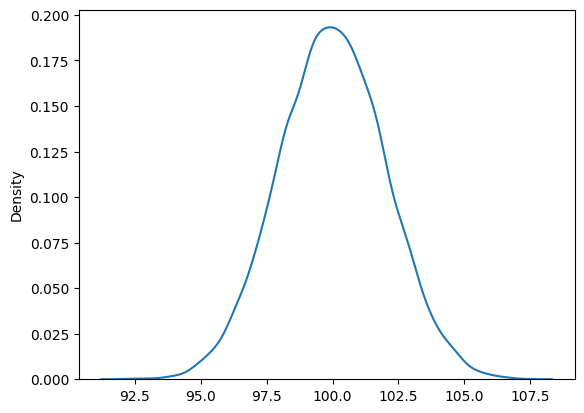

In [11]:
# now visualize it
sns.kdeplot(tmp)
plt.show() # get rid of annoying text

It's interesting to calculate the mean or percentiles of the distribution and PLOT them on the distribution.


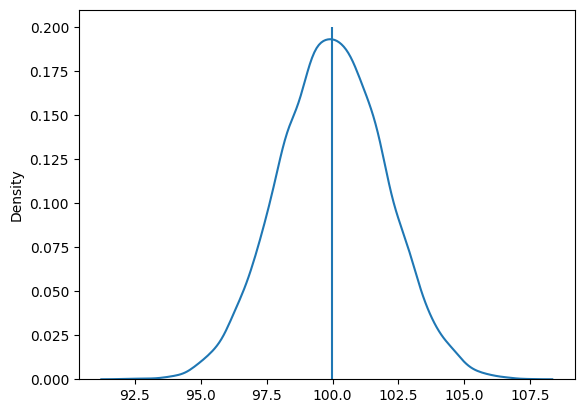

In [12]:
# like this! see how I dynamically updated the value on the plot? no hard coding! better!!!
sns.kdeplot(tmp)
vlines(x=np.mean(tmp),ymin=0, ymax=0.2) # you may need to adjust the ymax value
plt.show() # get rid of annoying text

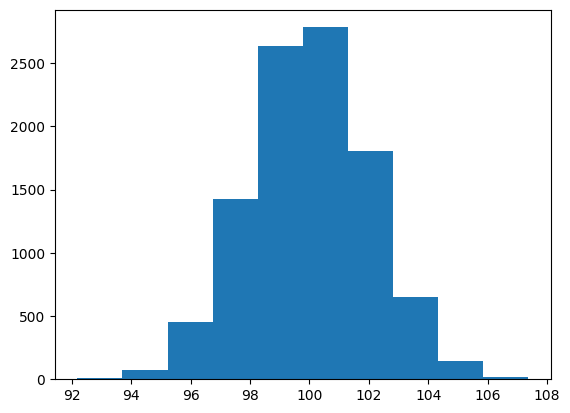

In [13]:
# you can also use a histogram
hist(tmp)
plt.show()

On your own, you can try adding a line to the histogram and customizing the style (solid vs. dashed) and color.


## 🔴 Triangular Distribution
This is THE business-estimate distribution. When a client can't give you data but CAN answer *"what's the worst case, the best case, and the most likely value?"* - that **three-point estimate** maps straight onto `left`, `right`, and `mode`. Bonus: unlike the normal, it's **bounded** - you can never draw a value outside [left, right].
* https://numpy.org/doc/stable/reference/random/generated/numpy.random.triangular.html#numpy.random.triangular

`random.triangular(left, mode, right, size=None)`
`left` is the left min, `right` is the right max, and `mode` is the most common.

Draw samples from the triangular distribution over the interval [left, right].

The triangular distribution is a continuous probability distribution with lower limit left, peak at mode, and upper limit right. Unlike the other distributions, these parameters directly define the shape of the pdf.

**From Powell:**

The triangular distribution describes an outcome that has a minimum and maximum
value but is most likely to occur at an intermediate point. The triangular distribution is
more flexible than the uniform because it can have a peak anywhere in its range. It is well
suited to situations where we can identify a most likely outcome as well as the smallest and
largest possible outcomes.
<!-- 🎙 DAVE TALKING POINTS (invisible when rendered - double-click this cell to read):
- OPEN: "The business-estimate distributions - what the client can actually tell you."
- Triangular = THREE-POINT ESTIMATE: worst / most-likely / best -> left / mode / right.
- Say BOUNDED, not censored. "You can never draw outside the range - no 8-sigma surprises."
- Uniform = the candy bar. Total ignorance between two bounds.
- CLOSE: "the appendix has more important distributions - binomial, Poisson - real tools worth exploring. Next video: the engine - for loops." (Calm + positive - they matter, the videos just focus elsewhere.)
-->


In [14]:
# let's generate one value from the triangular distribution
np.random.triangular(left=5, mode=10, right=20, size=1)

array([14.67814571])

In [15]:
# now 10,000 values - and we deliberately stretch the right tail out to 200
tmp = np.random.triangular(left=5, mode=10, right=200, size=10000)

In [16]:
tmp

array([148.72589277, 114.58204101,  57.25859988, ...,  92.73172783,
        52.22510159,  29.73875292], shape=(10000,))

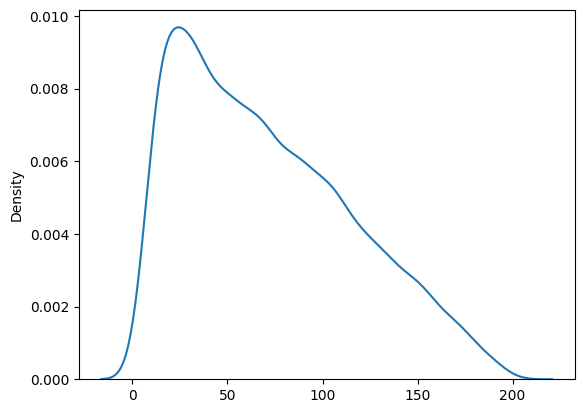

In [17]:
# plot it!
sns.kdeplot(tmp)
plt.show()

See how it is roughly triangular - with the long right tail we asked for? Compare `right=200` here vs `right=20` in the single draw: for this distribution the parameters ARE the shape. If you set size equal to like 1M perhaps it would be perfect?


**On your own:** try making a histogram with nice title and labels.


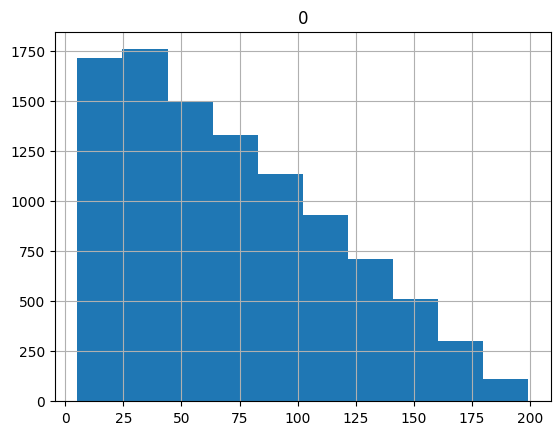

In [18]:
import pandas as pd
tmp = pd.DataFrame(tmp)
tmp.hist()
plt.show()

**On your own:** Of course, you can try to plot the mean or some percentiles of the distribution - can you count how many values are less than 7.5?


## Uniform Distribution
* https://numpy.org/doc/stable/reference/random/generated/numpy.random.uniform

`random.uniform(low=0.0, high=1.0, size=None)`

Draw samples from a uniform distribution.

Samples are uniformly distributed over the half-open interval [low, high) (includes low, but excludes high). In other words, any value within the given interval is equally likely to be drawn by uniform.

**From Powell:**
The uniform distribution describes an outcome that is equally likely to fall anywhere
between a prescribed minimum and a prescribed maximum. It is particularly appropriate
when we can make a reasonable guess about the smallest and largest possible outcomes
but have no reason to suspect that any values in between are more likely than others.


In [19]:
# generate one value
np.random.uniform(low=10, high=20, size=1)

array([13.54180617])

In [20]:
# generate 10k values
tmp = np.random.uniform(low=10, high=20, size=10000)

<Axes: ylabel='Density'>

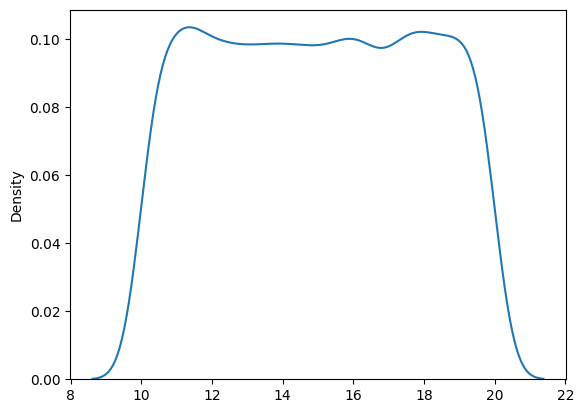

In [21]:
# plot it!
sns.kdeplot(tmp)

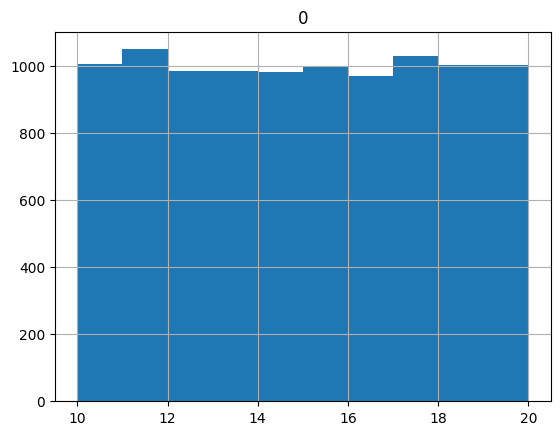

In [22]:
tmp = pd.DataFrame(tmp)
tmp.hist()
plt.show()

Again, you have lots of opportunies for customization! You can add a nice title and labels.

**On your own:** try the shade the area to the left of 12 and to the right of 18.
* https://stackoverflow.com/questions/46685453/how-to-fill-with-a-different-color-an-area-in-seaborn-distplot


# 🔴 For Loop
Loops are the ENGINE of Monte Carlo - one trial is just code, but a loop makes it ten thousand trials. Three examples, simple to hard. Keep your eye on one thing throughout: **a variable created OUTSIDE the loop survives every pass through it** - that's how a simulation carries your money from year to year.
<!-- 🎙 DAVE TALKING POINTS (invisible when rendered - double-click this cell to read):
- OPEN: "One trial is just code. A loop makes it ten thousand trials."
- np.arange: the stop value is NOT included.
- THE concept: a variable created OUTSIDE the loop survives every pass - that is how money carries year to year.
- Nested loops: "great exam question - predict c BEFORE you run."
- CLOSE: "next video we bolt a distribution onto this loop and simulate a retirement."
-->


## Example 1 - repeat something (easy)
The loop variable (`a` here - name it whatever you want) takes each value in the list, one at a time, and the indented block runs once per value. That's the whole trick.


In [23]:
# the loop variable takes each value, one at a time
colors = ['red', 'yellow', 'blue']
for a in colors:
  print(a)

red
yellow
blue


For simulations we usually loop over *numbers*, not colors - `np.arange(start, stop, step)` builds the list for us. **Caution:** the stop value is NOT included - `np.arange(0,5,1)` gives you 0,1,2,3,4.


In [24]:
# same idea with numbers - this is how we'll count years
for a in np.arange(0,5,1):
  print('Year:', a)

Year: 0
Year: 1
Year: 2
Year: 3
Year: 4


## Example 2 - accumulate (medium)
Now the important one. `current_val` is created **outside** the loop, so it survives every pass - each year adds to the total from the year before. This handoff is the beating heart of every simulation in this class.

**Predict before you run:** what will the final number be?


In [25]:
current_val = 0 # lives OUTSIDE the loop - it survives every pass
for i in np.arange(0,5,1):
  print('Year:', i)
  current_val = current_val + i # the handoff: new value = old value + this year's addition
  print('Value:', current_val)
print('This is how much money I have:', current_val)

Year: 0
Value: 0
Year: 1
Value: 1
Year: 2
Value: 3
Year: 3
Value: 6
Year: 4
Value: 10
This is how much money I have: 10


## Example 3 - nested loops (hard)
A loop *inside* a loop: for every pass of the outer loop, the inner loop runs all the way through. This is exactly the shape of our simulation - **outer loop = trials, inner loop = years**.

`c` lives outside BOTH loops, so it accumulates across all four inner passes.


In [26]:
# great exam question ... what is c? predict BEFORE you run!
c = 0
for a in np.arange(1,3,1): # outer loop (1,2)
  print('this is a:', a)
  print('------------------')
  for b in np.arange(3,5,1): #inner loop (3,4)
    print('this is b:', b)
    c = a + b + c # accumulates across BOTH loops
  print('====')
print('c is:', c)

this is a: 1
------------------
this is b: 3
this is b: 4
====
this is a: 2
------------------
this is b: 3
this is b: 4
====
c is: 20


**On your own:** change the inner loop to `np.arange(3,6,1)` and predict the new `c` before you run it. No credit for running first and "predicting" second ;)

That's all the machinery the simulation needs: Example 1 = do something each year, Example 2 = carry the balance forward, Example 3 = wrap 30 years inside 10,000 trials. Let's go.


# 🔴 Simple MC example - your first Monte Carlo simulation!
Time to put a distribution to WORK. Here's the question we'll answer: *if I save \$2,500 a month for 30 years and the market does what the market does, how much money might I retire with?*

Our assumptions, out loud (always write these down first):

- We start from **\$0** and contribute **\$2,500/month = \$30,000/year**
- We invest for **30 years**
- Each year the market return is drawn from a **Normal distribution: mean 8%, sd 17%** (roughly the S&P's personality)
- Each year's ending balance becomes next year's starting balance - that's the handoff
- No taxes, no fees, no inflation (a modeling choice - we know!)

Because the return is *random*, one 30-year career tells us almost nothing. So we'll simulate **10,000 careers** and look at the whole distribution of outcomes.
<!-- 🎙 DAVE TALKING POINTS (invisible when rendered - double-click this cell to read):
- OPEN with the question: "$2,500 a month, 30 years, the market does what the market does - what do you retire with?"
- Read the assumptions OUT LOUD - modeling choices are part of the answer.
- Get ONE year right first. Then the double loop, read outside-in.
- Histogram: right-skewed - most careers low millions, a lucky few explode.
- Percentiles = how you talk to a client about risk. "5% chance you retire with less than X."
- THE NUGGET: distribution -> one trial -> loop -> read the output distribution. Every sim in this class is this pattern in a different costume.
-->


First, get ONE year right - and a quick word on **seeds**. `np.random.seed()` pins the randomness so a cell produces the *same* draw every run (handy when you're teaching or debugging). Watch: the two cells below write the SAME distribution two different ways - a growth factor drawn directly, and `1 + return/100` - and because they use the same seed, they land on the **exact same number**. Same seed, same distribution, same draw.

In [ ]:
np.random.seed(5641)
np.random.normal(loc=1.08, scale = 0.17)

In [ ]:
# in our example below, we DON'T WANT a random seed because we need the randomness 10k times
# if we added this to the loop, we'd be in trouble

np.random.seed(5641)
1 + np.random.normal(loc=8, scale = 17)/100

**Caution:** that comment is the whole lesson - a seed INSIDE the simulation loop would hand every trial the identical "random" returns, and your 10,000 futures would collapse into one. Seed for demos, never inside the loop. (Comment the seeds out and re-run to feel the randomness again.)

Now wrap that one-year draw in the double for-loop, and read it from the outside in:

- **Outer loop** (`i`) = 10,000 simulated careers
- **Inner loop** (`a`) = the 30 years inside one career
- `rate = 1 + np.random.normal(...)/100` - a **fresh random return every year**
- `current_value = (current_value + contribution) * rate` - deposit, then grow. The updated `current_value` carries into the next year: **the handoff**
- `if a == 30:` - at the end of a career, store the final balance and move on to the next career

**Remember:** `resultDF` lives OUTSIDE both loops - that's why it can collect all 10,000 final balances.


In [28]:
# make an empty list for 30 year results
resultDF = []
for i in np.arange(0,10000,1):
  current_value = 0
  contribution = 2500*12
  for a in np.arange(1,31,1):
    #print('Year: ', a)
    # new rate every year!
    rate = 1 + np.random.normal(loc=8, scale = 17)/100
    #print('rate:', rate)
    current_value = (current_value + contribution) * rate
    #print('The value is:', current_value)

    # if it's the last year...
    if a == 30:
      #store the value
      resultDF.append(np.round(current_value,0))
print(resultDF[:5]) # peek at the first 5 careers - the real analysis comes next

[np.float64(952455.0), np.float64(4960807.0), np.float64(3700396.0), np.float64(3777483.0), np.float64(6566350.0)]


That wall of numbers is 10,000 possible retirements. Treat it like any dataset - describe it, plot it, take percentiles:


In [29]:
resultDF = pd.DataFrame(resultDF)
resultDF.describe()


,0
count,1.000000e+04
mean,3.660075e+06
std,2.631363e+06
min,2.676500e+05
25%,1.931577e+06
50%,2.929762e+06
75%,4.553356e+06
max,3.282385e+07


Look at the **shape**: right-skewed. Most careers land in the low millions, but a lucky few compound into monsters - and they drag the *mean* above the *median*. This shape is WHY we simulate instead of just multiplying averages.


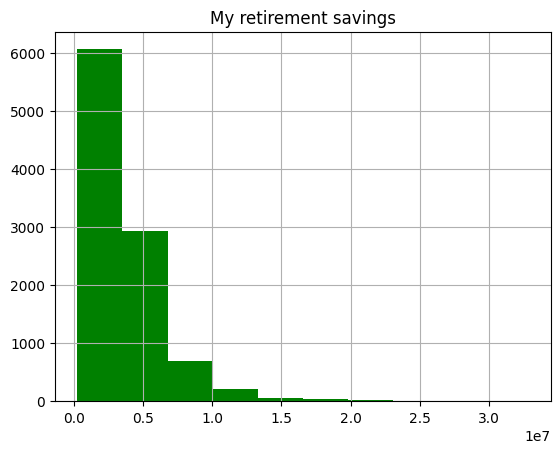

In [30]:
resultDF.hist(color='green')
plt.title('My retirement savings')
plt.show()


Percentiles are how you talk to a *client* about risk: "there's a 5% chance you retire with less than the 0.05 row, and a 5% chance with more than the 0.95 row." Nobody wants a single number - they want the range of futures.


In [31]:
resultDF.quantile([0,0.01, 0.05, 0.10, 0.20, 0.5, 0.80, 0.90, 0.95, 0.99, 1])

,0
0.00,267650.00
0.01,708330.56
0.05,1072872.15
0.10,1342431.20
0.20,1761238.80
0.50,2929762.50
0.80,5107705.20
0.90,6788422.20
0.95,8515628.85
0.99,13404952.40


🔷 **The nugget:** that's the entire Monte Carlo recipe - *describe uncertainty with a distribution, get one trial right, loop it thousands of times, then read the distribution of outcomes.* Every simulation you build in this class is this pattern wearing a different costume.

**On your own:** re-run the simulation with a contribution of \$1,000/month. How does the 5th-percentile retirement change? That's the number that should drive the savings decision.

*Next up: the **Big Ideas for MC Simulation** notebook - same retirement problem, but with real S&P data, parametric vs. nonparametric sampling, and spaghetti plots.*


## Bottom line

You've now got a little toolbox of distributions - normal, triangular, and uniform up front, with binomial, Poisson, and friends in the appendix. The *art* of Monte Carlo is picking the one that matches your real-world quantity (a stock return, a count of claims, a wait time) and then turning its knobs until it looks right. When in doubt, sample a bunch, plot it, and sanity-check it against what you'd actually expect.


# Appendix: more distributions worth knowing
*(No video for this section - explore at your own pace.)*

The workhorses above power the simulations in this module, but the **discrete** distributions below matter in the real world and may well show up in your projects and your career: counting defective chips in a batch (binomial), dice rolls and equally-likely choices (uniform integers), customer arrivals or claims per period (Poisson). They produce whole numbers - counts of things - rather than continuous values. Worth your time.


## Binomial Distribution
* https://numpy.org/doc/stable/reference/random/generated/numpy.random.binomial.html

`random.binomial(n, p, size=None)`

Draw samples from a binomial distribution.

Samples are drawn from a binomial distribution with specified parameters, n trials and p probability of success where n an integer >= 0 and p is in the interval [0,1]. (n may be input as a float, but it is truncated to an integer in use)

**From Powell:**

A useful distribution is the binomial distribution, which describes a random
variable that counts the number of successful outcomes in a series of n independent
experiments (trials), each with a success probability of p. The possible outcomes are the
numbers 0, 1, 2, ..., n. Suppose we are counting the number of defective chips in a
production batch of n 100. (As is often the case in quality control, we can represent a
defect as a “success.”) If we know that there is a 5 percent chance that an individual chip is
defective, then the number of defects in the batch can be modeled as following a binomial
distribution with parameters n 100 and p 0.05 (see Figure A3.5d). We need two
parameters to specify a binomial distribution - the number of trials and the success rate.


In [32]:
# out of fifty trials, how many successes would I find?
np.random.binomial(n=50, p=0.2, size=1)

array([9], dtype=int32)

In [33]:
# generate 10k samples
tmp = np.random.binomial(n=50, p=0.2, size=10000)

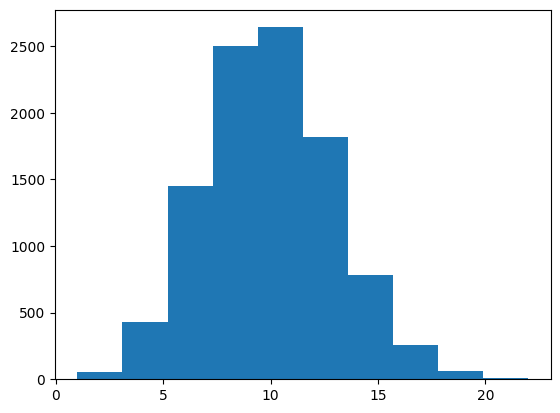

In [34]:
# plot it!
hist(tmp)
plt.show()

Of course, as n goes to infinity, you approximate a normal distribution (which is awesome!)


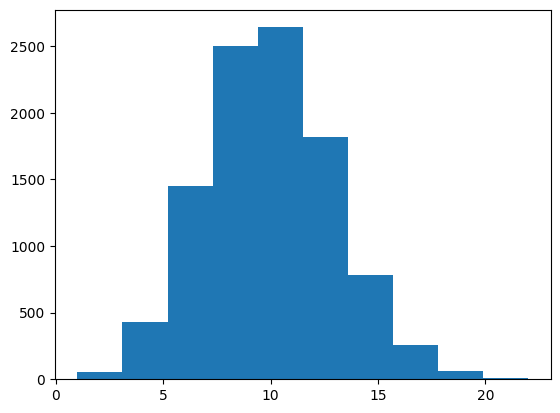

In [35]:
# histograms are probably a bit nicer since it's integers
hist(tmp)
plt.show()

**On your own:** Try to play with the values of `p` and `n` and also the bin size in the histogram.


## Uniform Integers
* https://numpy.org/doc/stable/reference/random/generated/numpy.random.randint.html#numpy.random.randint

`random.randint(low, high=None, size=None, dtype=int)`

Return random integers from low (inclusive) to high (exclusive).

Return random integers from the “discrete uniform” distribution of the specified dtype in the “half-open” interval [low, high). If high is None (the default), then results are from [0, low).

**From Powell:**
The integer uniform distribution can be used when the outcomes can be numbered 1
through n, and each outcome occurs with equal probability. The result of rolling a fair die
can be described by an integer uniform distribution with six outcomes, as shown in
Figure A3.5b.


In [36]:
# generate a single value
np.random.randint(low=15, high=62, size=1, dtype=int)

array([36], dtype=int32)

In [37]:
# generate 10k values
tmp = np.random.randint(low=15, high=62, size=10000, dtype=int)

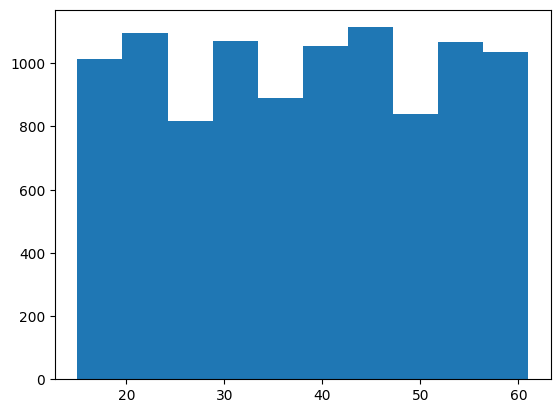

In [38]:
# plot it!
hist(tmp)
plt.show()

If you up the number of samples it will approach the true PDF.

**On your own:** Play with the bin size and number of samples drawn.


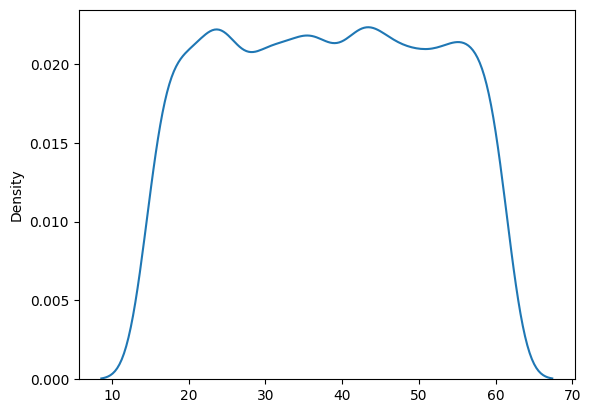

In [39]:
# a kde on integers - see why the histogram above reads better?
sns.kdeplot(tmp)
plt.show()

## Poisson Distribution
* https://numpy.org/doc/stable/reference/random/generated/numpy.random.poisson.html

`random.poisson(lam=1.0, size=None)`

Draw samples from a Poisson distribution.

The Poisson distribution is the limit of the binomial distribution for large N.
**What it's for:** counts of events in a fixed window - customer arrivals per hour, insurance claims per month, typos per page. `lam` (lambda) is the average count per window.

⚠️ **Common mix-up:** Poisson is *how many* events happen in a window. The *waiting time between* events is a different distribution (the **exponential**). If a call center gets `lam=10` calls/hour (Poisson), the gap between calls averages 6 minutes (exponential).


In [40]:
# generate one value from the poisson distribution
np.random.poisson(lam=3, size=1)

array([2], dtype=int32)

In [41]:
# make 1000 values
tmp = np.random.poisson(lam=2, size=10000)

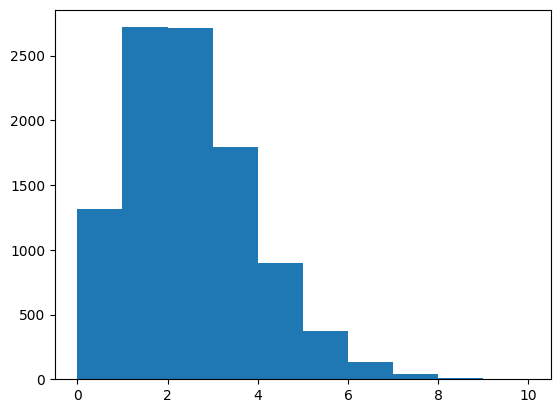

In [42]:
# plot it!
hist(tmp)
plt.show()

**On your own:** Try different values of lambda and investigate how this changes the distribution.


# [optional] Cumulative density function
This code will work for any of the large samples we generated! Not for single values (`size=1`).


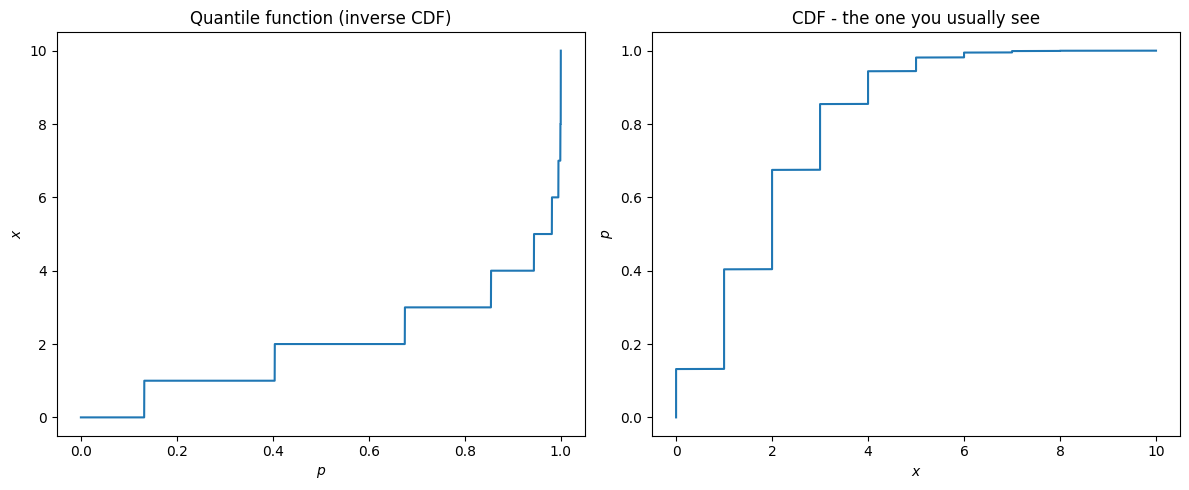

In [43]:
# cdf
data = tmp

# sort the data:
data_sorted = np.sort(data)

# calculate the proportional values of samples
p = 1. * np.arange(len(data)) / (len(data) - 1)

# plot the sorted data - wider figure so the two panels don't crowd each other
fig = plt.figure(figsize=(12, 5))

ax1 = fig.add_subplot(121)
ax1.plot(p, data_sorted)
ax1.set_xlabel('$p$')
ax1.set_ylabel('$x$')
ax1.set_title('Quantile function (inverse CDF)')

ax2 = fig.add_subplot(122)
ax2.plot(data_sorted, p)
ax2.set_xlabel('$x$')
ax2.set_ylabel('$p$')
ax2.set_title('CDF - the one you usually see')

plt.tight_layout() # spread the panels out
plt.show()         # ...and no stray Text(...) output above the figure

See how you can read off the percentiles? The **righthand plot is the standard CDF** - the value $x$ on the horizontal axis, cumulative probability $p$ on the vertical - and it's the version you'll see everywhere. The left plot is its mirror image, the *quantile function*: give it a probability, it hands you back the value.


In [44]:
import numpy as np
np.percentile(tmp, [0, 25, 50, 75, 100])

array([ 0.,  1.,  2.,  3., 10.])

**On your own:** Try to add these percentiles to the plot.
